# CardioAI: Inteligencia Artificial aplicada al riesgo cardiovascular

Este notebook desarrolla un clasificador binario para predecir la presencia de enfermedad cardiovascular utilizando el **Heart Disease UCI Dataset** y el algoritmo **XGBoost**.

El flujo completo incluye:
1. Instalación e importación de librerías
2. Lectura y Análisis Exploratorio de Datos (EDA)
3. Preprocesamiento
4. Entrenamiento del modelo mejorado
5. Evaluación
6. Exportación del modelo para producción (Streamlit)

## 1. Instalación de las librerías

Importamos las librerías necesarias para análisis de datos, visualización y modelado.
- **pandas / numpy**: manipulación y cálculo numérico
- **matplotlib / seaborn**: visualizaciones estadísticas
- **xgboost**: modelo de gradient boosting
- **scikit-learn**: partición de datos y métricas de evaluación
- **json / os**: exportación del modelo para producción

In [87]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns

## 2. Lectura y EDA del dataset

Cargamos el dataset y realizamos un análisis exhaustivo para entender la estructura de los datos, la distribución de las variables y su relación con la variable objetivo (`num`).

In [88]:
df = pd.read_csv("heart_disease_uci.csv")

El dataset **Heart Disease UCI** combina datos de cuatro fuentes clínicas (Cleveland, Hungarian, Switzerland y VA Long Beach) con un total de 920 pacientes y 16 variables.

In [89]:
df.shape

(920, 16)

In [90]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


Convertimos todas las columnas de tipo `object` o `str` a códigos numéricos enteros usando `cat.codes`, que asigna un entero a cada categoría única.

In [92]:
for col in df.columns:
    if df[col].dtype == 'str' or df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

La columna `num` contiene 5 niveles (0–4), donde cualquier valor mayor que 0 indica presencia de enfermedad. La convertimos a binaria: **0 = Sin enfermedad**, **1 = Con enfermedad**.

In [93]:
df["num"].unique().tolist()


[0, 2, 1, 3, 4]

In [94]:
df["num"] = (df["num"] > 0).astype(int)
df['num'].unique().tolist()

[0, 1]

Analizamos el porcentaje de valores nulos por columna para decidir qué variables incluir en el modelo.

In [95]:
(df.isna().mean() * 100).sort_values(ascending=False)

ca          66.413043
oldpeak      6.739130
trestbps     6.413043
thalch       5.978261
chol         3.260870
dataset      0.000000
id           0.000000
age          0.000000
fbs          0.000000
cp           0.000000
sex          0.000000
restecg      0.000000
exang        0.000000
slope        0.000000
thal         0.000000
num          0.000000
dtype: float64

**Eliminamos** columnas no predictivas: `id`, `dataset`, `ca` (66% faltantes), `thal` (53% faltantes)

In [96]:
df = df.drop(columns=["id", "dataset", "ca", "thal"])

In [97]:
df["num"].value_counts(normalize=True)

num
1    0.553261
0    0.446739
Name: proportion, dtype: float64

In [98]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
count,920.000000,920.000000,920.000000,861.000000,890.000000,920.000000,920.000000,865.000000,920.000000,858.000000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,132.132404,199.130337,0.052174,0.985870,137.545665,0.306522,0.878788,0.480435,0.553261
std,9.424685,0.408148,0.956350,19.066070,110.780810,0.495349,0.638633,25.926276,0.576622,1.091226,1.167966,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,60.000000,-1.000000,-2.600000,-1.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,175.000000,0.000000,1.000000,120.000000,0.000000,0.000000,-1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,140.000000,0.000000,0.500000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,1.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000


Los histogramas nos permiten ver la forma de la distribución de cada variable continua.

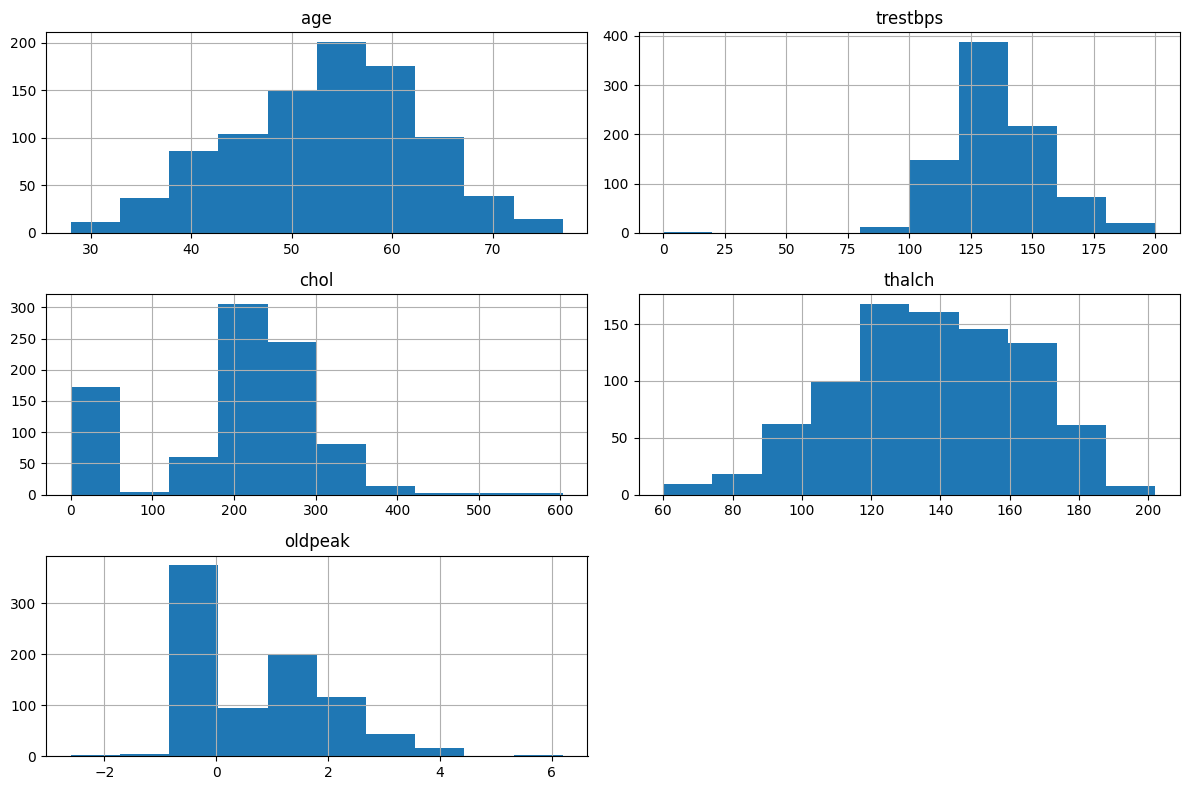

In [99]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Los boxplots muestran cómo se distribuye cada variable numérica según la presencia (1) o ausencia (0) de enfermedad. Diferencias claras en la mediana sugieren poder predictivo.

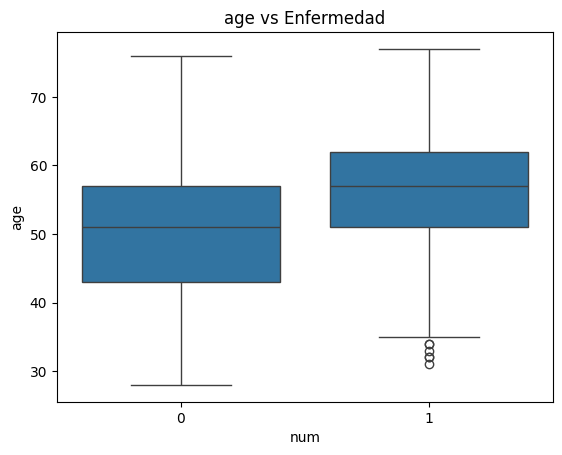

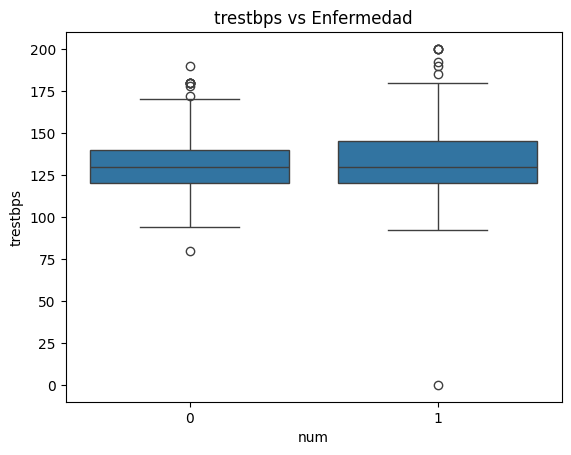

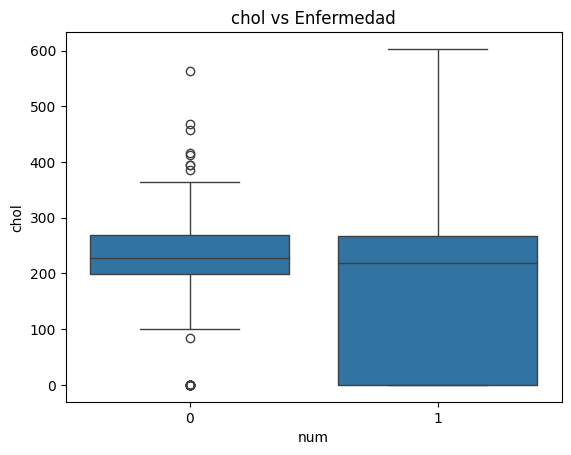

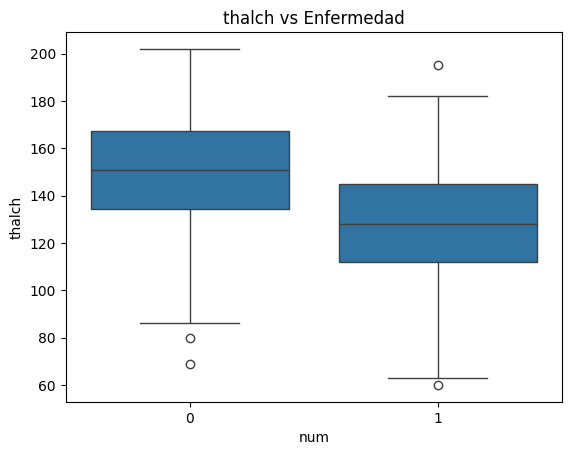

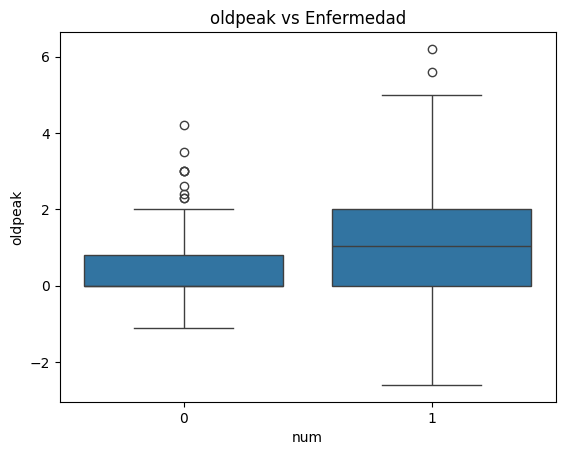

In [100]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x="num", y=col, data=df)
    plt.title(f"{col} vs Enfermedad")
    plt.show()

Tablas de contingencia normalizadas que muestran la proporción de pacientes con y sin enfermedad dentro de cada categoría.

In [101]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
for col in cat_cols:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df["num"], normalize="index"))


sex
num         0         1
sex                    
0    0.742268  0.257732
1    0.367769  0.632231

cp
num         0         1
cp                     
0    0.209677  0.790323
1    0.862069  0.137931
2    0.642157  0.357843
3    0.565217  0.434783

fbs
num         0         1
fbs                    
-1   0.155556  0.844444
 0   0.510116  0.489884
 1   0.318841  0.681159

restecg
num             0         1
restecg                    
-1       0.000000  1.000000
 0       0.436170  0.563830
 1       0.486388  0.513612
 2       0.340782  0.659218

exang
num           0         1
exang                    
-1     0.363636  0.636364
 0     0.636364  0.363636
 1     0.163205  0.836795

slope
num           0         1
slope                    
-1     0.624595  0.375405
 0     0.222222  0.777778
 1     0.228986  0.771014
 2     0.615764  0.384236


El heatmap muestra las correlaciones de Pearson entre todas las variables numéricas. Valores cercanos a ±1 indican alta correlación lineal.

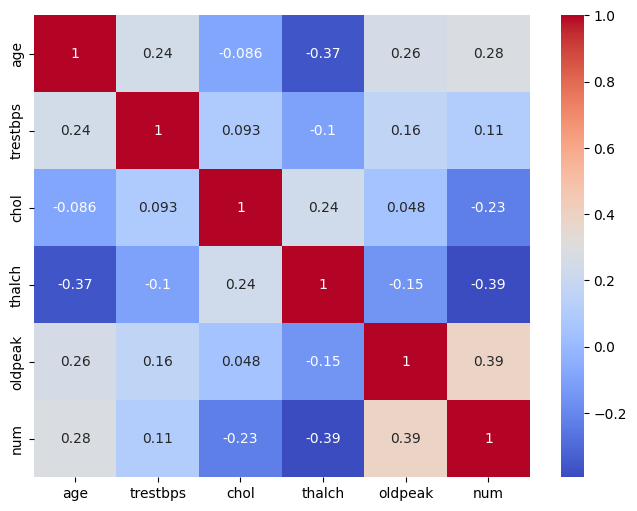

In [102]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ["num"]].corr(), annot=True, cmap="coolwarm")
plt.show()

## 3. Pre-procesamiento

Preparamos los datos para el entrenamiento:

1. **Renombramos** la columna `num` a `target` para mayor claridad
2. **Dividimos** en conjuntos de entrenamiento (80%) y prueba (20%) con estratificación para mantener el balance de clases


In [103]:
df = df.rename(columns={'num':'target'})
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'target'],
      dtype='str')

In [104]:
FEATURES = df.drop("target", axis=1).columns.tolist()
X = df.drop('target', axis=1)
Y = df['target']

In [105]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

## 4. Modelado

Usamos **XGBoost Classifier** con hiperparámetros optimizados:

1. `n_estimators=200`
- Número de árboles que se construyen.
- Más árboles = modelo más potente, pero más lento y con riesgo de sobreajuste.
- “cuántos intentos hace el modelo para mejorar”.
2. `learning_rate=0.05`
- Qué tan rápido aprende el modelo en cada paso.
- Valores bajos → aprendizaje más lento pero más preciso.
- Es como dar pasos pequeños pero seguros.
3. `max_depth=4`
- Profundidad máxima de cada árbol.
- Más profundidad = más complejidad (puede sobreajustar).
- Árboles muy profundos “memorizan”, árboles poco profundos “generalizan”.
4. `subsample=0.8`
- Porcentaje de datos usados para entrenar cada árbol.
- 0.8 = usa el 80% de los datos en cada iteración.
- Introduce aleatoriedad → reduce sobreajuste.
5. `colsample_bytree=0.8`
- Porcentaje de variables (features) usadas por cada árbol.
- Hace que los árboles sean distintos entre sí → mejora robustez.
6. `random_state=42`
- Semilla para reproducibilidad.
- Garantiza que obtengas los mismos resultados cada vez.
7. `use_label_encoder=False`
- Desactiva un método antiguo de codificación de etiquetas.
- Se pone en `False` porque ya no se recomienda usarlo.
8. `eval_metric="logloss"`
- Métrica para evaluar el desempeño durante entrenamiento.
- `logloss` mide qué tan bien predice probabilidades.
- Penaliza más los errores “seguros pero incorrectos”.
9. `verbosity=0`
- Controla cuánto imprime el modelo en consola.
- 0 = silencioso.
- Útil para no llenar la terminal de logs innecesarios.

In [106]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    verbosity=0
)

model.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 5. Evaluación

Evaluamos el modelo entrenado sobre el conjunto de prueba con múltiples métricas:

- **Accuracy**: porcentaje de predicciones correctas
- **Precision**: de los predichos como positivos, ¿cuántos realmente lo son?
- **Recall**: de los realmente positivos, ¿cuántos detectamos?
- **F1-Score**: media armónica de Precision y Recall
- **AUC-ROC**: capacidad discriminativa general del modelo

In [107]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

- **Accuracy: 84.78%**
  - El modelo acierta ~85 de cada 100 casos.
  - Buen desempeño general.

- **AUC-ROC: 0.91**
  - Capacidad de distinguir entre clases.
  - auc>0.9 = excelente separación.

In [108]:
acc = accuracy_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_prob)
print(f"  Accuracy : {acc} ({acc*100:.2f}%)")
print(f"  AUC-ROC  : {auc}")

  Accuracy : 0.8478260869565217 (84.78%)
  AUC-ROC  : 0.9058103975535169


In [109]:
print(confusion_matrix(Y_test, y_pred))


[[62 13]
 [15 94]]


- **62** → verdaderos negativos (bien)
- **94** → verdaderos positivos (bien)
- **13** → falsos positivos (error)
- **15** → falsos negativos (error)

In [110]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        75
           1       0.88      0.86      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



1. Clase 0
- **Precision: 0.81**
  - De lo que predijo como 0, el 81% era correcto
- **Recall: 0.83**
  - Detecta el 83% de los verdaderos 0

2. Clase 1
- **Precision: 0.88**
  - Muy confiable cuando predice 1
- **Recall: 0.86**
  - Detecta bien los positivos

3. F1-score (balance)
- Clase 0 → 0.82  
- Clase 1 → 0.87  
Mejor desempeño en clase 1.

4. Promedios
- **Macro avg: 0.84**
  - Trata ambas clases por igual
- **Weighted avg: 0.85**
  - Ajustado al tamaño de cada clase

> El modelo es **ligeramente mejor detectando la clase 1**, pero en general está bien balanceado.

XGBoost calcula la importancia de cada variable según cuántas veces se usa para dividir los datos y cuánto mejora la predicción.

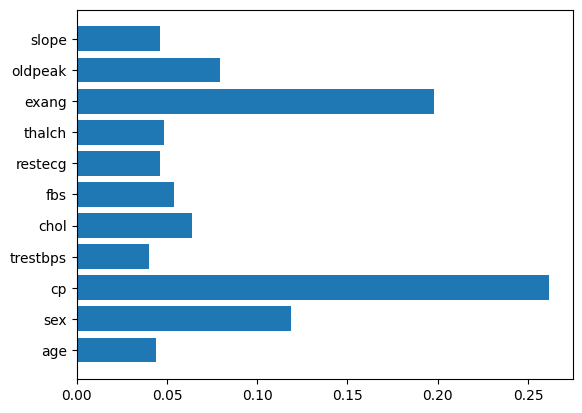

In [111]:
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.show()

Para desplegar el modelo en Streamlit necesitamos guardar dos artefactos:

1. **`cardioai_model.json`** — El modelo XGBoost serializado en formato JSON nativo de XGBoost. Este formato es más robusto y portable que el pickle de Python (no depende de la versión de Python o de la librería).

2. **`feature_names.json`** — Lista ordenada de los nombres de las features, en el mismo orden que se usaron durante el entrenamiento. Esto es **crítico** para que las predicciones en producción sean correctas.

Ambos archivos se guardan en la carpeta `model/` dentro del repositorio.

In [112]:
# Crear carpeta de modelo si no existe
os.makedirs("model", exist_ok=True)

# 1. Guardar modelo XGBoost en formato JSON
model_path = "model/cardioai_model.json"
model.save_model(model_path)
print(f"Modelo guardado en: {model_path}")

# 2. Guardar lista de features en orden correcto
features_path = "model/feature_names.json"
with open(features_path, "w") as f:
    json.dump(FEATURES, f, indent=2)
print(f"Feature names guardados en: {features_path}")
print(f"Features: {FEATURES}")

# Verificación de carga
test_model = XGBClassifier()
test_model.load_model(model_path)
test_pred = test_model.predict(X_test)
test_acc = accuracy_score(Y_test, test_pred)
print(f"Accuracy del modelo recargado: {test_acc:.4f} ")
assert abs(test_acc - acc) < 1e-6, "❌ Error: el modelo recargado no coincide"


Modelo guardado en: model/cardioai_model.json
Feature names guardados en: model/feature_names.json
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope']
Accuracy del modelo recargado: 0.8478 


**Próximo paso:** Ejecutar el notebook `streamlit_deploy.ipynb` para crear y desplegar la aplicación web.